<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/oman_policy_analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

first policy of oman

Policy : Omanisation_Policy
Policy Year : 1994

========== DESCRIPTIVE ANALYSIS ==========

Before Policy
count         3.0
mean     250000.0
std       15000.0
min      235000.0
25%      242500.0
50%      250000.0
75%      257500.0
max      265000.0
Name: Migration, dtype: float64

After Policy
count        33.000000
mean     552121.212121
std      169742.591439
min      280000.000000
25%      370000.000000
50%      585000.000000
75%      685000.000000
max      795000.000000
Name: Migration, dtype: float64

Mean Before : 250000.0
Mean After  : 552121.21
Difference  : 302121.21


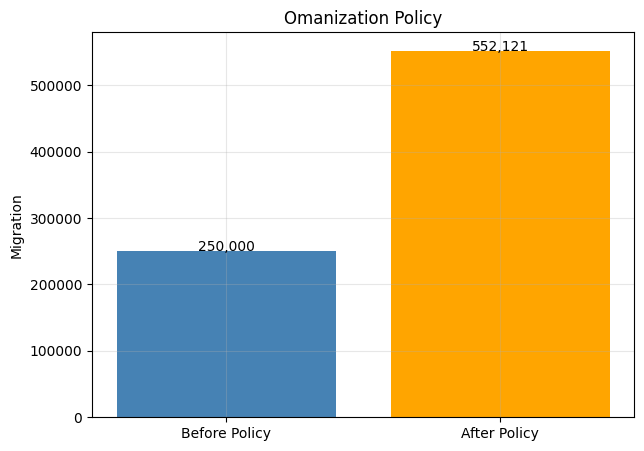


Variance Explained
[0.6234 0.2587 0.0866]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.948
Method:                 Least Squares   F-statistic:                     110.4
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           4.49e-19
Time:                        15:55:51   Log-Likelihood:                -443.16
No. Observations:                  37   AIC:                             900.3
Df Residuals:                      30   BIC:                             911.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

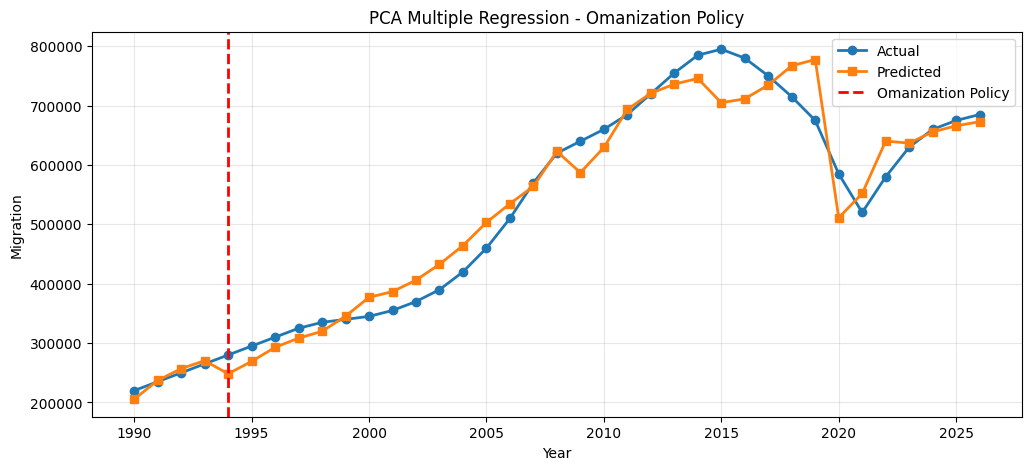

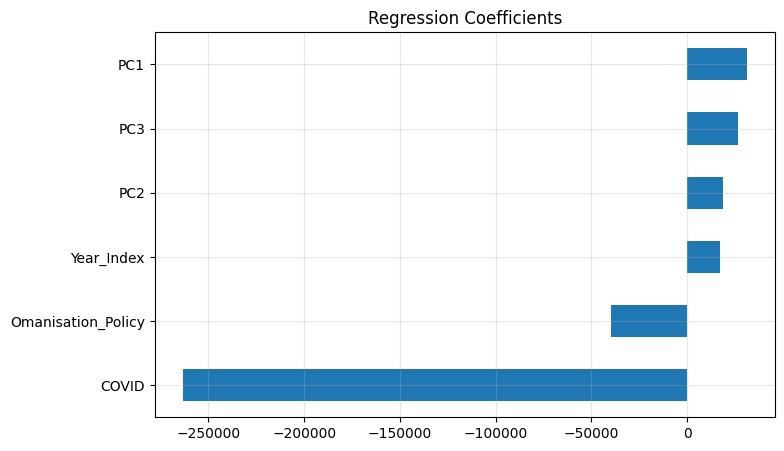

ENHANCED INTERRUPTED TIME SERIES
Policy : Omanisation_Policy
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     129.4
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.65e-20
Time:                        15:55:51   Log-Likelihood:                -436.52
No. Observations:                  37   AIC:                             893.0
Df Residuals:                      27   BIC:                             909.1
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


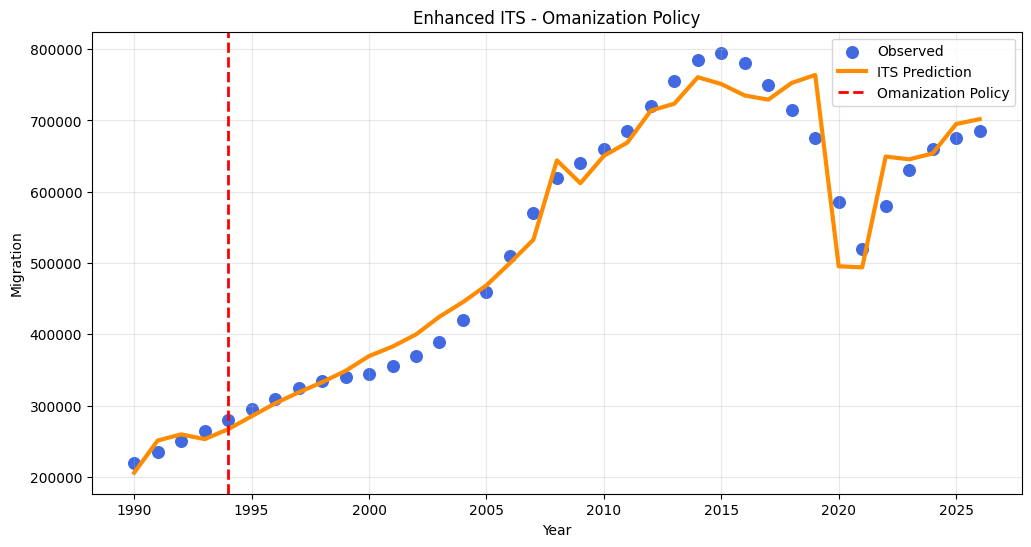

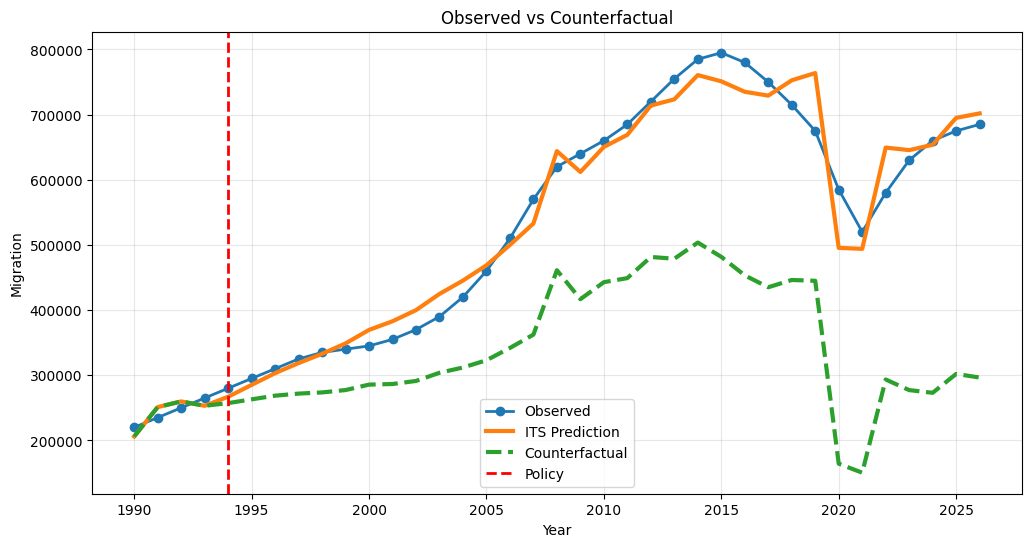

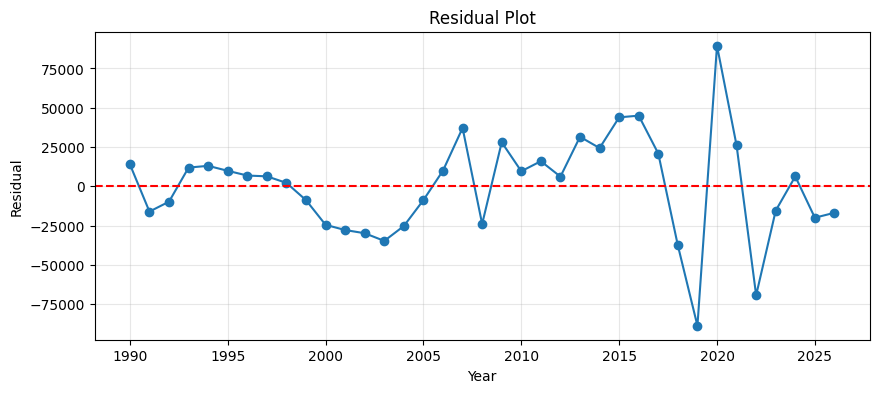

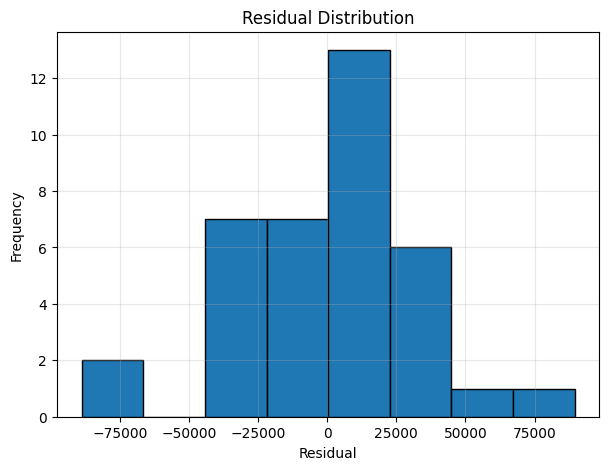


Durbin-Watson : 1.748

INTERPRETATION
✗ No statistically significant immediate change in migration after the policy.
✗ No statistically significant long-term trend change after the policy.

Estimated Immediate Effect : 9781.76
Estimated Annual Trend Change : 6181.51


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

oman = df[df["Country"]=="Oman"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Omanisation_Policy"

policy_year = oman.loc[
    oman[policy] == 1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = oman[
    (oman["Year"] >= policy_year-3) &
    (oman["Year"] < policy_year)
]

after = oman[
    oman["Year"] >= policy_year
]

print("\n========== DESCRIPTIVE ANALYSIS ==========")

print("\nBefore Policy")
print(before["Migration"].describe())

print("\nAfter Policy")
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before Policy","After Policy"],
    [before_mean,after_mean],
    color=["steelblue","orange"]
)

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        f"{b.get_height():,.0f}",
        ha="center"
    )

plt.title("Omanization Policy")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

oman["COVID"]=(oman["Year"]>=2020).astype(int)

oman["Year_Index"]=oman["Year"]-oman["Year"].min()

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=oman[economic_variables]

X=X.fillna(X.median())

y=oman["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(
    pca.explained_variance_ratio_,
    4
))

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=oman.index
)

reg_data=pd.concat([

pca_df,

oman[[

"Migration",
"COVID",
"Year_Index",
policy

]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(
    formula,
    data=reg_data
).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\n========== MODEL PERFORMANCE ==========")

print(
"R² :",
round(
r2_score(
reg_data["Migration"],
reg_data["Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"]
)
),2)
)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

oman["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

oman["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("PCA Multiple Regression - Omanization Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# REGRESSION COEFFICIENTS
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()


# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# OMANIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# SORT DATA
# ======================================================

oman = oman.sort_values("Year").copy()

# ======================================================
# TIME VARIABLES
# ======================================================

oman["Time"] = oman["Year"] - policy_year

# Policy Indicator

oman["Policy"] = (oman["Year"] >= policy_year).astype(int)

# Time After Policy

oman["Time_After"] = oman["Time"].clip(lower=0)

# Interaction

oman["Policy_Time"] = oman["Policy"] * oman["Time_After"]

# COVID Dummy

oman["COVID"] = (oman["Year"] >= 2020).astype(int)

# ======================================================
# ENHANCED ITS MODEL
# ======================================================

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=oman

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ======================================================
# PREDICTION
# ======================================================

oman["ITS_Prediction"] = its.predict(oman)

# ======================================================
# MODEL PERFORMANCE
# ======================================================

print("\nITS PERFORMANCE")
print("-"*40)

print(
"R² :",
round(
r2_score(
oman["Migration"],
oman["ITS_Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
oman["Migration"],
oman["ITS_Prediction"]
)
),2)
)

# ======================================================
# POLICY EFFECT
# ======================================================

print("\nPolicy Effect")
print("-"*40)

print("Immediate Level Change :", round(its.params["Policy"],2))
print("Trend Change :", round(its.params["Policy_Time"],2))
print("Time Effect :", round(its.params["Time"],2))

print("\nP-values")
print("Policy :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ======================================================
# OBSERVED VS PREDICTED
# ======================================================

plt.figure(figsize=(12,6))

plt.scatter(

oman["Year"],
oman["Migration"],

s=70,

color="royalblue",

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

color="darkorange",

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("Enhanced ITS - Omanization Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# COUNTERFACTUAL
# ======================================================

counter = oman.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

oman["Year"],
oman["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

label="ITS Prediction"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# RESIDUALS
# ======================================================

oman["Residuals"] = (

oman["Migration"] -

oman["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

oman["Year"],

oman["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# RESIDUAL HISTOGRAM
# ======================================================

plt.figure(figsize=(7,5))

plt.hist(

oman["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# DURBIN-WATSON
# ======================================================

dw = durbin_watson(its.resid)

print("\nDurbin-Watson :", round(dw,3))

# ======================================================
# INTERPRETATION
# ======================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Omanization Policy caused a statistically significant immediate change in migration.")
else:
    print("✗ No statistically significant immediate change in migration after the policy.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ The long-term migration trend changed significantly after the policy.")
else:
    print("✗ No statistically significant long-term trend change after the policy.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

In [ ]:
df.columns

Index(['Country', 'Year', 'GDP', 'Inflation', 'Population', 'Migration',
       'Migration_Flow', 'Oil_Price', 'Exchange_Rate', 'Unemployment',
       'Kafala_Sponsorship_System', 'Kuwaitization_Policy',
       'Domestic_Workers_Law_No_68', 'Residency_Law_Reforms',
       'Labour_Market_Reform', 'Privat_Sector_Labor_Law',
       'Foreigners_Residency_Law_No_114', 'Omanisation_Policy',
       'Labour_Law_Royal_Decree_35', 'Visa_Ban_Policy',
       'Expansion_of_Omanisation', 'Labour_Law_Reform_2023',
       'Bahrainization_Policy', 'Labour_Market_Reform_Law_2006',
       'Labour_Law_No_36', 'Flexi_Permit', 'Labour_Registration_Program'],
      dtype='object')

second policy of oman

Policy : Labour_Law_Royal_Decree_35
Policy Year : 2003

========== DESCRIPTIVE ANALYSIS ==========

Before Policy
count         3.000000
mean     356666.666667
std       12583.057392
min      345000.000000
25%      350000.000000
50%      355000.000000
75%      362500.000000
max      370000.000000
Name: Migration, dtype: float64

After Policy
count        24.000000
mean     636041.666667
std      113357.640722
min      390000.000000
25%      577500.000000
50%      660000.000000
75%      716250.000000
max      795000.000000
Name: Migration, dtype: float64

Mean Before : 356666.67
Mean After  : 636041.67
Difference  : 279375.0


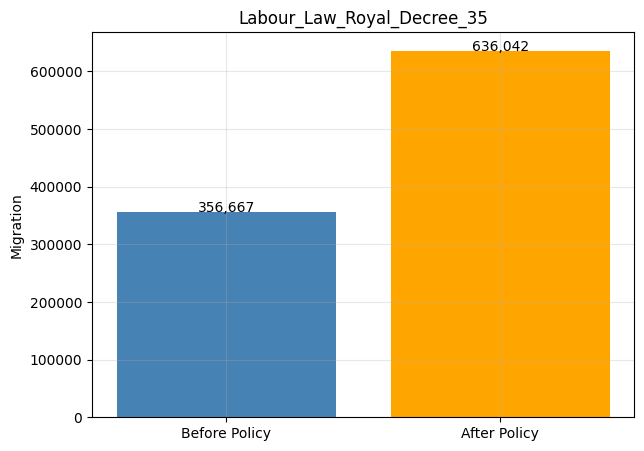


Variance Explained
[0.6234 0.2587 0.0866]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     106.3
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.64e-19
Time:                        15:55:58   Log-Likelihood:                -443.82
No. Observations:                  37   AIC:                             901.6
Df Residuals:                      30   BIC:                             912.9
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

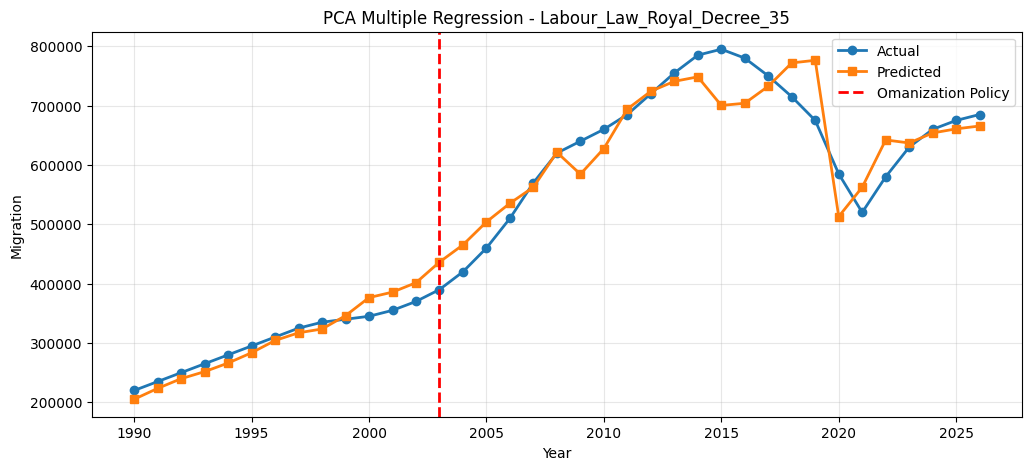

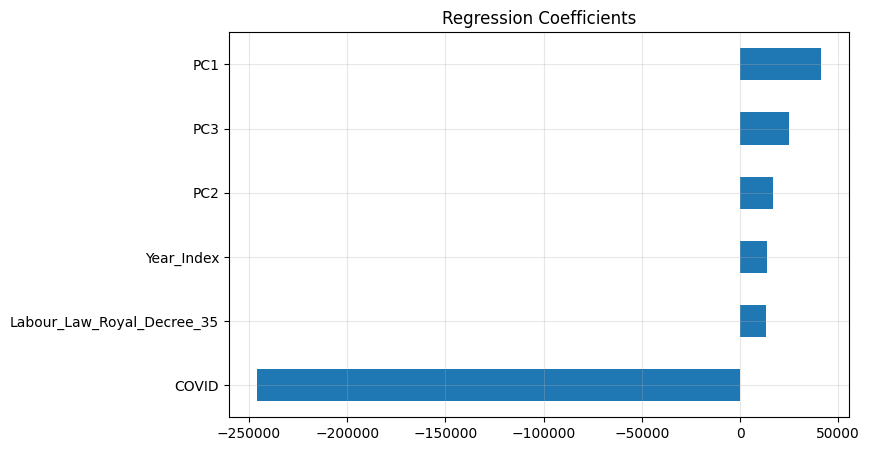

ENHANCED INTERRUPTED TIME SERIES
Policy : Labour_Law_Royal_Decree_35
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.972
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     189.8
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           4.91e-22
Time:                        15:55:58   Log-Likelihood:                -435.04
No. Observations:                  37   AIC:                             890.1
Df Residuals:                      27   BIC:                             906.2
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


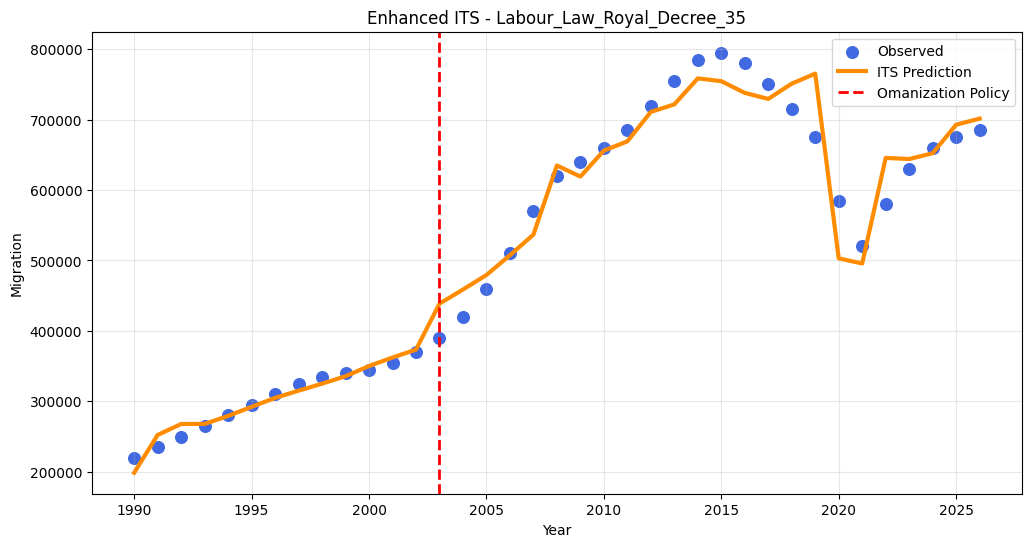

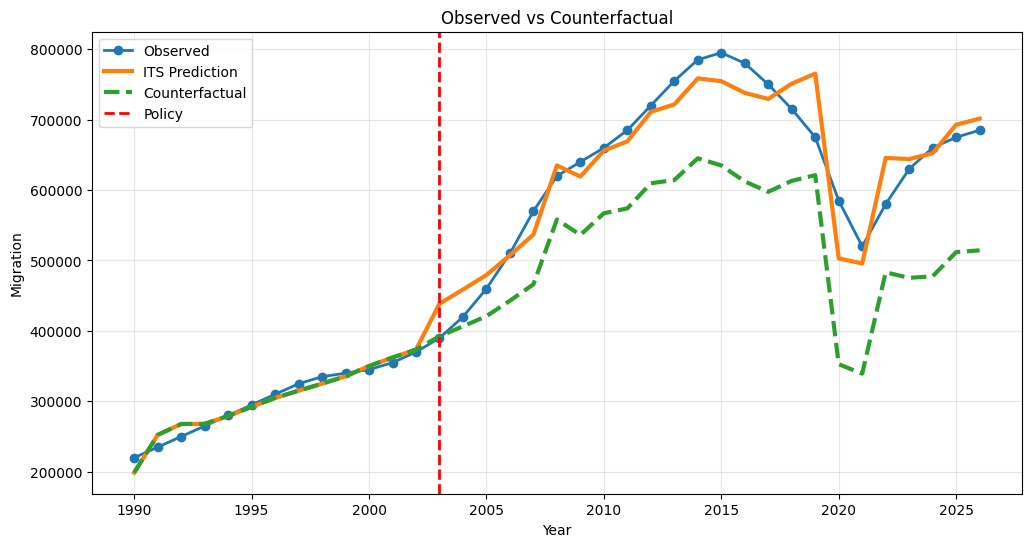

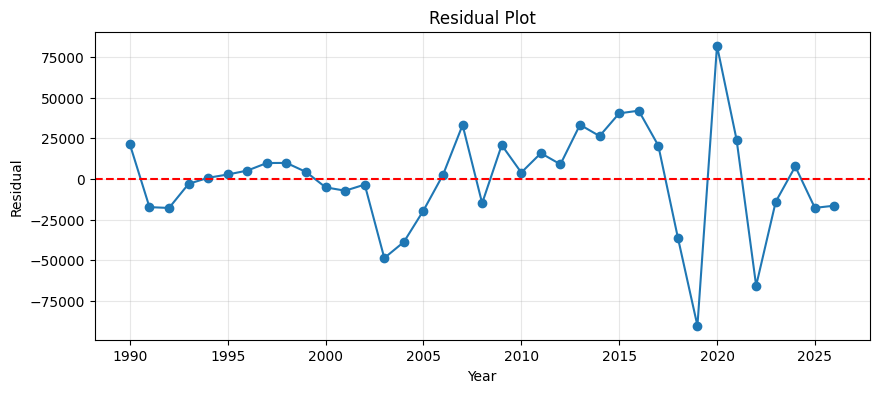

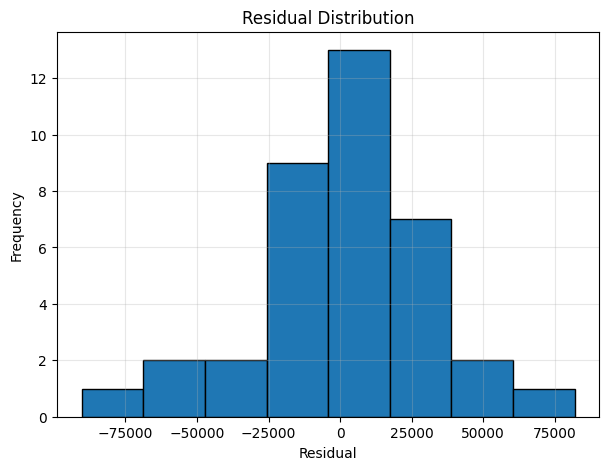


Durbin-Watson : 1.762

INTERPRETATION
✗ No statistically significant immediate change in migration after the policy.
✗ No statistically significant long-term trend change after the policy.

Estimated Immediate Effect : 46139.1
Estimated Annual Trend Change : 3062.77


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

oman = df[df["Country"]=="Oman"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Labour_Law_Royal_Decree_35"

policy_year = oman.loc[
    oman[policy] == 1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = oman[
    (oman["Year"] >= policy_year-3) &
    (oman["Year"] < policy_year)
]

after = oman[
    oman["Year"] >= policy_year
]

print("\n========== DESCRIPTIVE ANALYSIS ==========")

print("\nBefore Policy")
print(before["Migration"].describe())

print("\nAfter Policy")
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before Policy","After Policy"],
    [before_mean,after_mean],
    color=["steelblue","orange"]
)

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        f"{b.get_height():,.0f}",
        ha="center"
    )

plt.title("Labour_Law_Royal_Decree_35")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

oman["COVID"]=(oman["Year"]>=2020).astype(int)

oman["Year_Index"]=oman["Year"]-oman["Year"].min()

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=oman[economic_variables]

X=X.fillna(X.median())

y=oman["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(
    pca.explained_variance_ratio_,
    4
))

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=oman.index
)

reg_data=pd.concat([

pca_df,

oman[[

"Migration",
"COVID",
"Year_Index",
policy

]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(
    formula,
    data=reg_data
).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\n========== MODEL PERFORMANCE ==========")

print(
"R² :",
round(
r2_score(
reg_data["Migration"],
reg_data["Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"]
)
),2)
)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

oman["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

oman["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("PCA Multiple Regression - Labour_Law_Royal_Decree_35")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# REGRESSION COEFFICIENTS
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()


# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# OMANIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# SORT DATA
# ======================================================

oman = oman.sort_values("Year").copy()

# ======================================================
# TIME VARIABLES
# ======================================================

oman["Time"] = oman["Year"] - policy_year

# Policy Indicator

oman["Policy"] = (oman["Year"] >= policy_year).astype(int)

# Time After Policy

oman["Time_After"] = oman["Time"].clip(lower=0)

# Interaction

oman["Policy_Time"] = oman["Policy"] * oman["Time_After"]

# COVID Dummy

oman["COVID"] = (oman["Year"] >= 2020).astype(int)

# ======================================================
# ENHANCED ITS MODEL
# ======================================================

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=oman

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ======================================================
# PREDICTION
# ======================================================

oman["ITS_Prediction"] = its.predict(oman)

# ======================================================
# MODEL PERFORMANCE
# ======================================================

print("\nITS PERFORMANCE")
print("-"*40)

print(
"R² :",
round(
r2_score(
oman["Migration"],
oman["ITS_Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
oman["Migration"],
oman["ITS_Prediction"]
)
),2)
)

# ======================================================
# POLICY EFFECT
# ======================================================

print("\nPolicy Effect")
print("-"*40)

print("Immediate Level Change :", round(its.params["Policy"],2))
print("Trend Change :", round(its.params["Policy_Time"],2))
print("Time Effect :", round(its.params["Time"],2))

print("\nP-values")
print("Policy :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ======================================================
# OBSERVED VS PREDICTED
# ======================================================

plt.figure(figsize=(12,6))

plt.scatter(

oman["Year"],
oman["Migration"],

s=70,

color="royalblue",

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

color="darkorange",

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("Enhanced ITS - Labour_Law_Royal_Decree_35")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# COUNTERFACTUAL
# ======================================================

counter = oman.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

oman["Year"],
oman["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

label="ITS Prediction"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# RESIDUALS
# ======================================================

oman["Residuals"] = (

oman["Migration"] -

oman["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

oman["Year"],

oman["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# RESIDUAL HISTOGRAM
# ======================================================

plt.figure(figsize=(7,5))

plt.hist(

oman["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# DURBIN-WATSON
# ======================================================

dw = durbin_watson(its.resid)

print("\nDurbin-Watson :", round(dw,3))

# ======================================================
# INTERPRETATION
# ======================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Omanization Policy caused a statistically significant immediate change in migration.")
else:
    print("✗ No statistically significant immediate change in migration after the policy.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ The long-term migration trend changed significantly after the policy.")
else:
    print("✗ No statistically significant long-term trend change after the policy.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

third policy of oman

Policy : Visa_Ban_Policy
Policy Year : 2013

========== DESCRIPTIVE ANALYSIS ==========

Before Policy
count         3.000000
mean     688333.333333
std       30138.568867
min      660000.000000
25%      672500.000000
50%      685000.000000
75%      702500.000000
max      720000.000000
Name: Migration, dtype: float64

After Policy
count        14.000000
mean     685000.000000
std       84694.019406
min      520000.000000
25%      637500.000000
50%      680000.000000
75%      753750.000000
max      795000.000000
Name: Migration, dtype: float64

Mean Before : 688333.33
Mean After  : 685000.0
Difference  : -3333.33


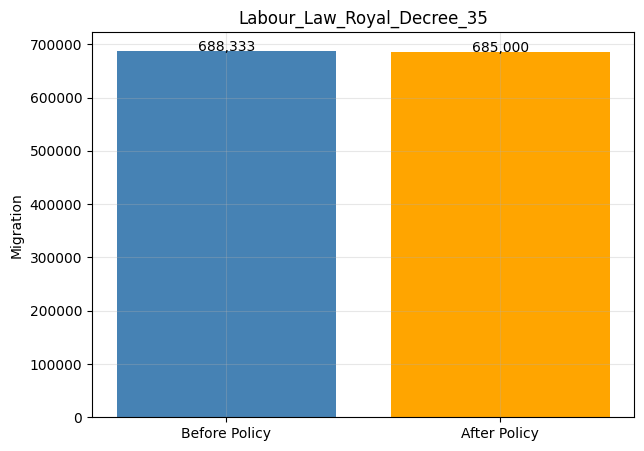


Variance Explained
[0.6234 0.2587 0.0866]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.952
Method:                 Least Squares   F-statistic:                     119.6
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.43e-19
Time:                        15:56:04   Log-Likelihood:                -441.74
No. Observations:                  37   AIC:                             897.5
Df Residuals:                      30   BIC:                             908.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

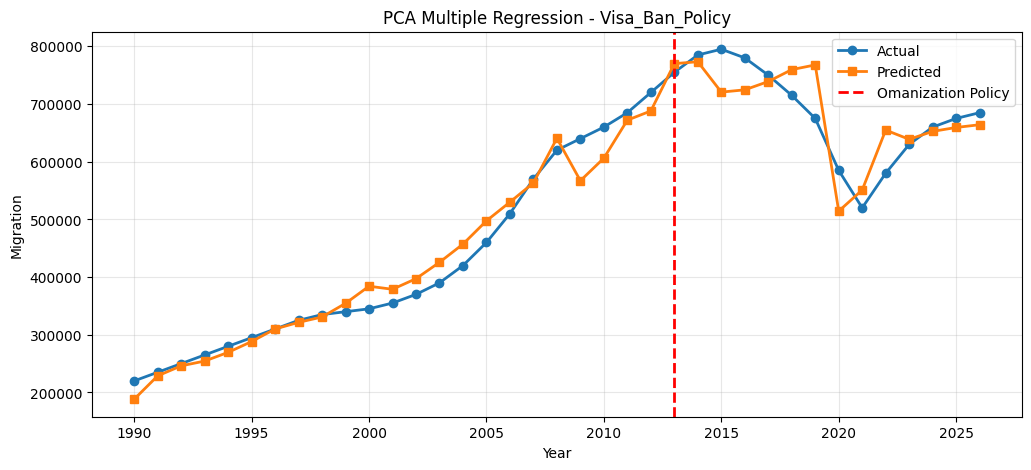

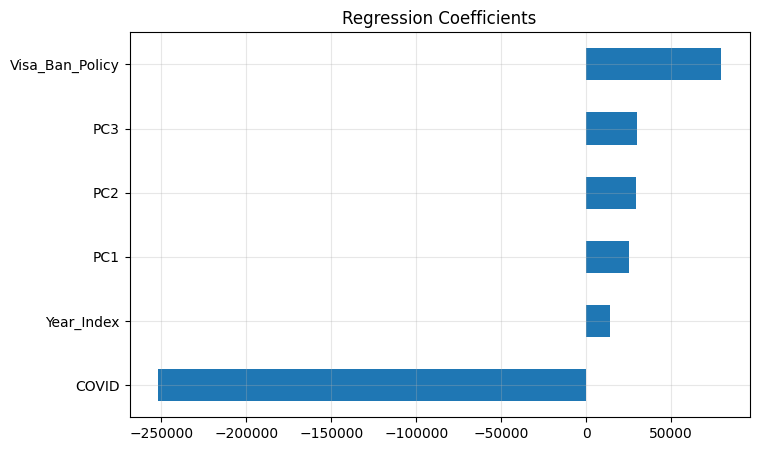

ENHANCED INTERRUPTED TIME SERIES
Policy : Visa_Ban_Policy
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     246.0
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           1.57e-23
Time:                        15:56:05   Log-Likelihood:                -424.84
No. Observations:                  37   AIC:                             869.7
Df Residuals:                      27   BIC:                             885.8
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


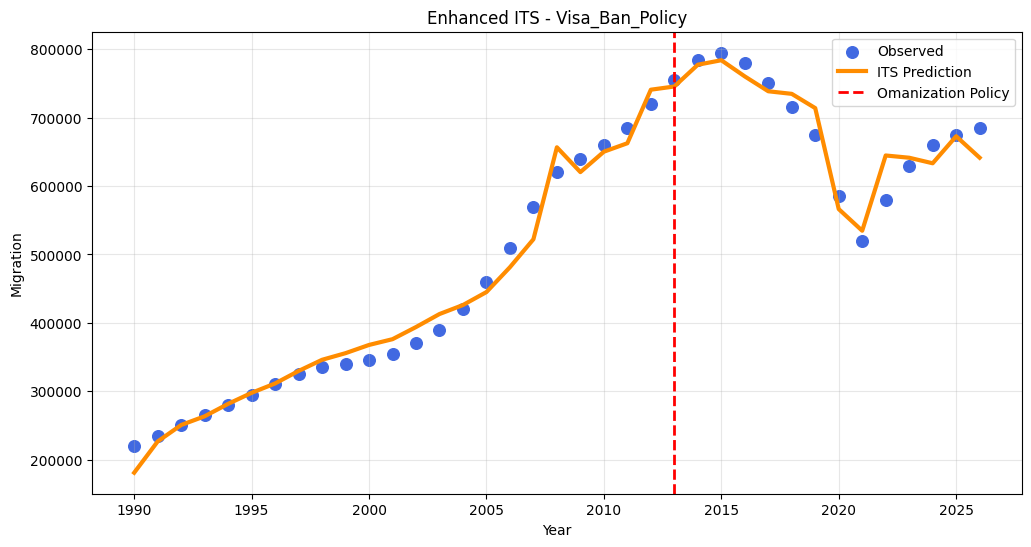

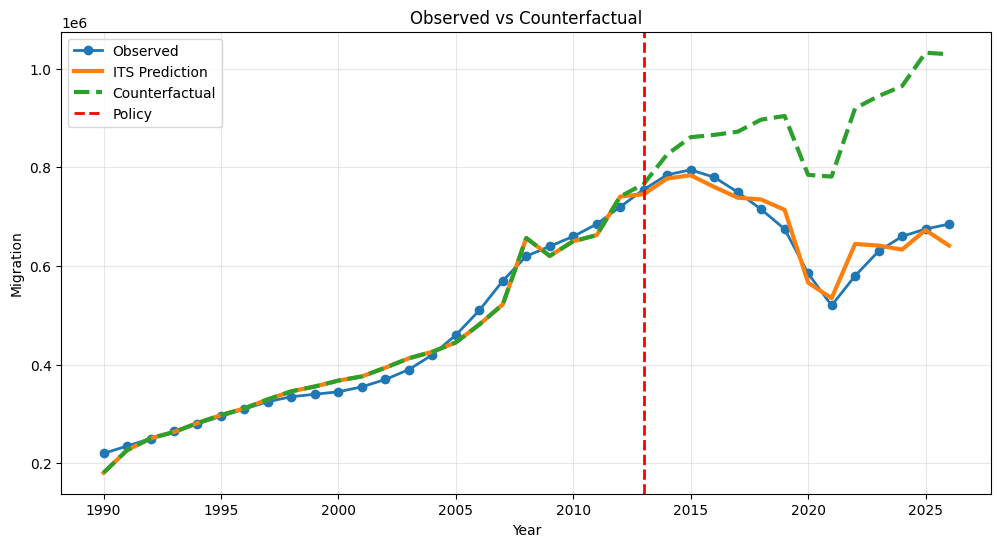

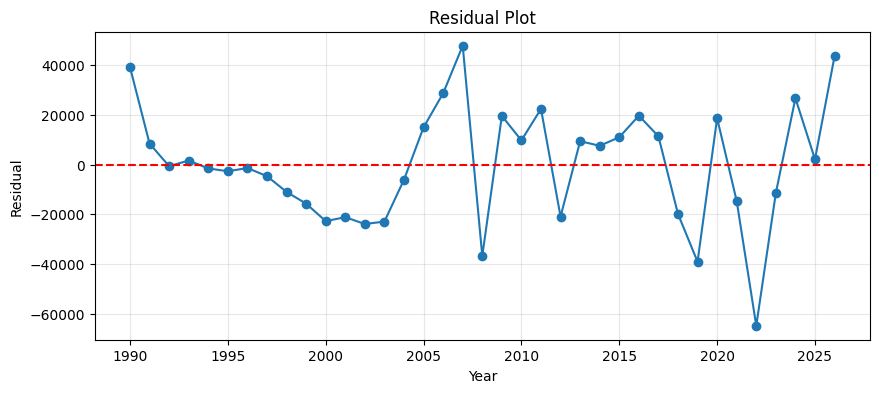

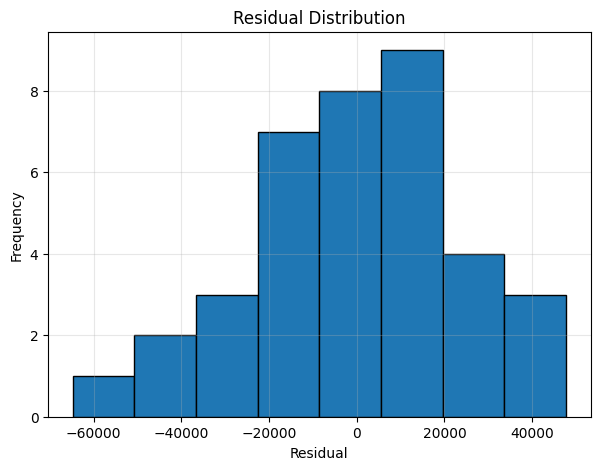


Durbin-Watson : 1.514

INTERPRETATION
✗ No statistically significant immediate change in migration after the policy.
✓ The long-term migration trend changed significantly after the policy.

Estimated Immediate Effect : -20764.57
Estimated Annual Trend Change : -14118.67


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

oman = df[df["Country"]=="Oman"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Visa_Ban_Policy"

policy_year = oman.loc[
    oman[policy] == 1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = oman[
    (oman["Year"] >= policy_year-3) &
    (oman["Year"] < policy_year)
]

after = oman[
    oman["Year"] >= policy_year
]

print("\n========== DESCRIPTIVE ANALYSIS ==========")

print("\nBefore Policy")
print(before["Migration"].describe())

print("\nAfter Policy")
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before Policy","After Policy"],
    [before_mean,after_mean],
    color=["steelblue","orange"]
)

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        f"{b.get_height():,.0f}",
        ha="center"
    )

plt.title("Labour_Law_Royal_Decree_35")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

oman["COVID"]=(oman["Year"]>=2020).astype(int)

oman["Year_Index"]=oman["Year"]-oman["Year"].min()

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=oman[economic_variables]

X=X.fillna(X.median())

y=oman["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(
    pca.explained_variance_ratio_,
    4
))

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=oman.index
)

reg_data=pd.concat([

pca_df,

oman[[

"Migration",
"COVID",
"Year_Index",
policy

]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(
    formula,
    data=reg_data
).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\n========== MODEL PERFORMANCE ==========")

print(
"R² :",
round(
r2_score(
reg_data["Migration"],
reg_data["Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"]
)
),2)
)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

oman["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

oman["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("PCA Multiple Regression - Visa_Ban_Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# REGRESSION COEFFICIENTS
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()


# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# OMANIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# SORT DATA
# ======================================================

oman = oman.sort_values("Year").copy()

# ======================================================
# TIME VARIABLES
# ======================================================

oman["Time"] = oman["Year"] - policy_year

# Policy Indicator

oman["Policy"] = (oman["Year"] >= policy_year).astype(int)

# Time After Policy

oman["Time_After"] = oman["Time"].clip(lower=0)

# Interaction

oman["Policy_Time"] = oman["Policy"] * oman["Time_After"]

# COVID Dummy

oman["COVID"] = (oman["Year"] >= 2020).astype(int)

# ======================================================
# ENHANCED ITS MODEL
# ======================================================

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=oman

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ======================================================
# PREDICTION
# ======================================================

oman["ITS_Prediction"] = its.predict(oman)

# ======================================================
# MODEL PERFORMANCE
# ======================================================

print("\nITS PERFORMANCE")
print("-"*40)

print(
"R² :",
round(
r2_score(
oman["Migration"],
oman["ITS_Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
oman["Migration"],
oman["ITS_Prediction"]
)
),2)
)

# ======================================================
# POLICY EFFECT
# ======================================================

print("\nPolicy Effect")
print("-"*40)

print("Immediate Level Change :", round(its.params["Policy"],2))
print("Trend Change :", round(its.params["Policy_Time"],2))
print("Time Effect :", round(its.params["Time"],2))

print("\nP-values")
print("Policy :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ======================================================
# OBSERVED VS PREDICTED
# ======================================================

plt.figure(figsize=(12,6))

plt.scatter(

oman["Year"],
oman["Migration"],

s=70,

color="royalblue",

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

color="darkorange",

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("Enhanced ITS - Visa_Ban_Policy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# COUNTERFACTUAL
# ======================================================

counter = oman.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

oman["Year"],
oman["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

label="ITS Prediction"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# RESIDUALS
# ======================================================

oman["Residuals"] = (

oman["Migration"] -

oman["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

oman["Year"],

oman["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# RESIDUAL HISTOGRAM
# ======================================================

plt.figure(figsize=(7,5))

plt.hist(

oman["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# DURBIN-WATSON
# ======================================================

dw = durbin_watson(its.resid)

print("\nDurbin-Watson :", round(dw,3))

# ======================================================
# INTERPRETATION
# ======================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Omanization Policy caused a statistically significant immediate change in migration.")
else:
    print("✗ No statistically significant immediate change in migration after the policy.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ The long-term migration trend changed significantly after the policy.")
else:
    print("✗ No statistically significant long-term trend change after the policy.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

fourth policy of oman

Policy : Expansion_of_Omanisation
Policy Year : 2024

========== DESCRIPTIVE ANALYSIS ==========

Before Policy
count         3.000000
mean     576666.666667
std       55075.705473
min      520000.000000
25%      550000.000000
50%      580000.000000
75%      605000.000000
max      630000.000000
Name: Migration, dtype: float64

After Policy
count         3.000000
mean     673333.333333
std       12583.057392
min      660000.000000
25%      667500.000000
50%      675000.000000
75%      680000.000000
max      685000.000000
Name: Migration, dtype: float64

Mean Before : 576666.67
Mean After  : 673333.33
Difference  : 96666.67


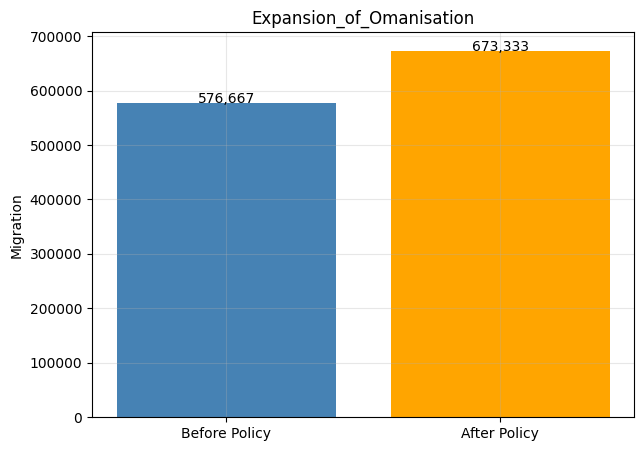


Variance Explained
[0.6234 0.2587 0.0866]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     107.3
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           6.71e-19
Time:                        15:56:13   Log-Likelihood:                -443.66
No. Observations:                  37   AIC:                             901.3
Df Residuals:                      30   BIC:                             912.6
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

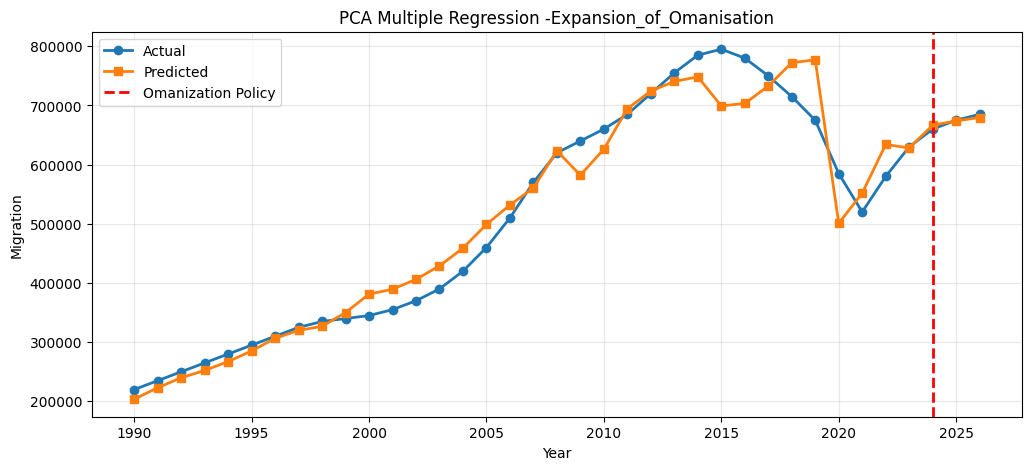

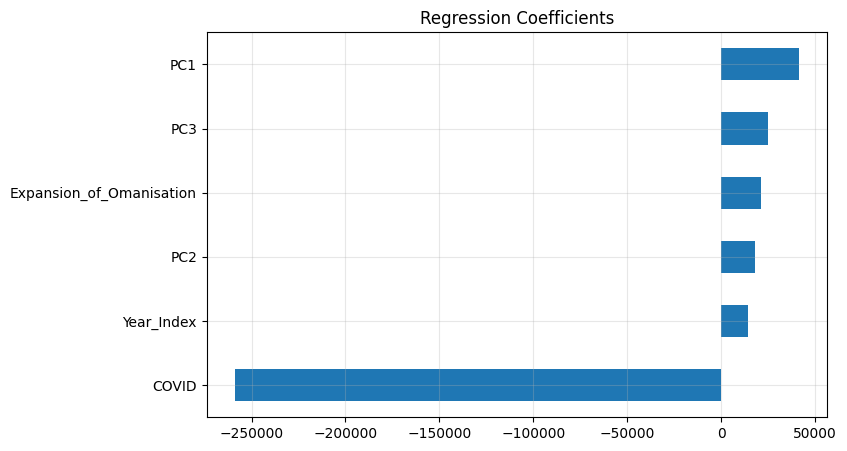

ENHANCED INTERRUPTED TIME SERIES
Policy : Expansion_of_Omanisation
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     184.1
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.36e-22
Time:                        15:56:14   Log-Likelihood:                -436.65
No. Observations:                  37   AIC:                             893.3
Df Residuals:                      27   BIC:                             909.4
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


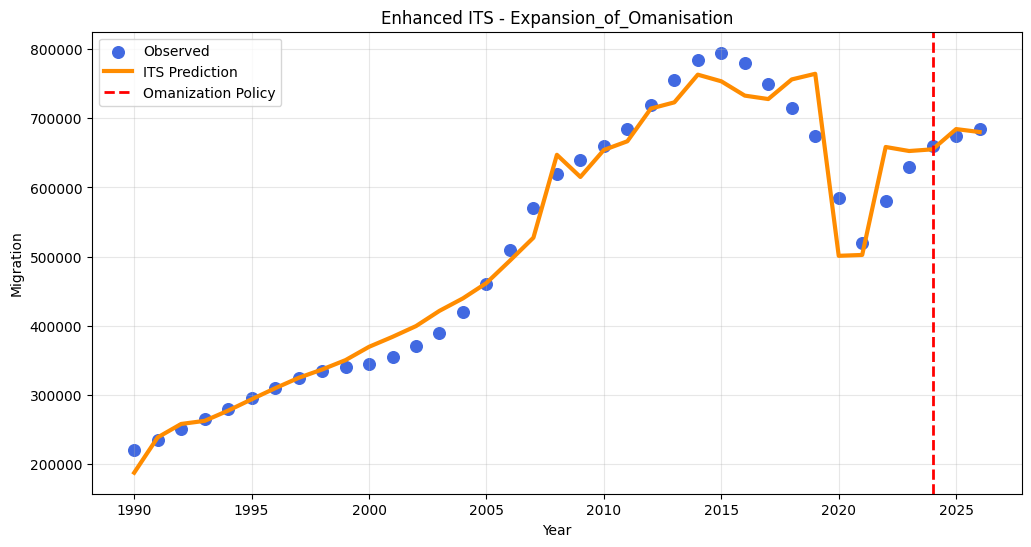

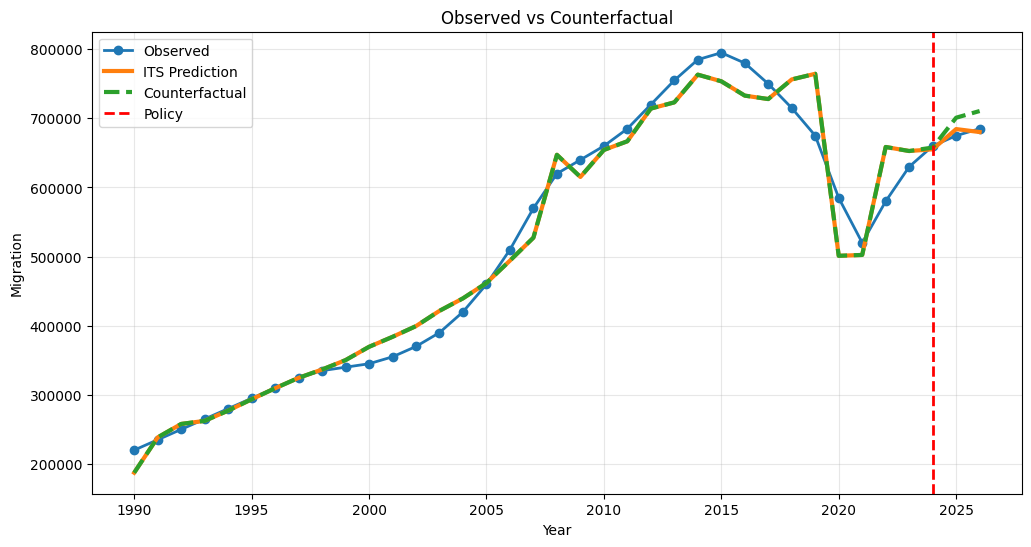

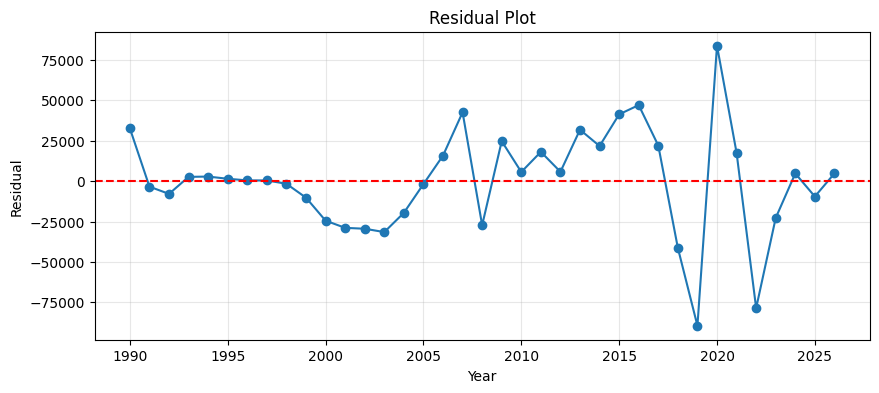

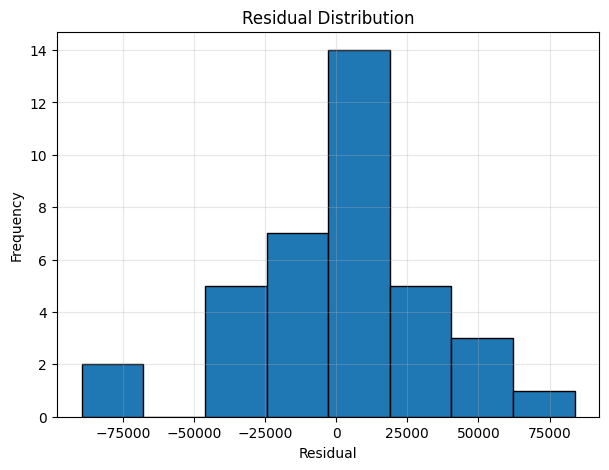


Durbin-Watson : 1.754

INTERPRETATION
✗ No statistically significant immediate change in migration after the policy.
✗ No statistically significant long-term trend change after the policy.

Estimated Immediate Effect : -2562.8
Estimated Annual Trend Change : -6956.34


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

oman = df[df["Country"]=="Oman"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Expansion_of_Omanisation"

policy_year = oman.loc[
    oman[policy] == 1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = oman[
    (oman["Year"] >= policy_year-3) &
    (oman["Year"] < policy_year)
]

after = oman[
    oman["Year"] >= policy_year
]

print("\n========== DESCRIPTIVE ANALYSIS ==========")

print("\nBefore Policy")
print(before["Migration"].describe())

print("\nAfter Policy")
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before Policy","After Policy"],
    [before_mean,after_mean],
    color=["steelblue","orange"]
)

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        f"{b.get_height():,.0f}",
        ha="center"
    )

plt.title("Expansion_of_Omanisation")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

oman["COVID"]=(oman["Year"]>=2020).astype(int)

oman["Year_Index"]=oman["Year"]-oman["Year"].min()

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=oman[economic_variables]

X=X.fillna(X.median())

y=oman["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(
    pca.explained_variance_ratio_,
    4
))

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=oman.index
)

reg_data=pd.concat([

pca_df,

oman[[

"Migration",
"COVID",
"Year_Index",
policy

]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(
    formula,
    data=reg_data
).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\n========== MODEL PERFORMANCE ==========")

print(
"R² :",
round(
r2_score(
reg_data["Migration"],
reg_data["Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"]
)
),2)
)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

oman["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

oman["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("PCA Multiple Regression -Expansion_of_Omanisation")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# REGRESSION COEFFICIENTS
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()


# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# OMANIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# SORT DATA
# ======================================================

oman = oman.sort_values("Year").copy()

# ======================================================
# TIME VARIABLES
# ======================================================

oman["Time"] = oman["Year"] - policy_year

# Policy Indicator

oman["Policy"] = (oman["Year"] >= policy_year).astype(int)

# Time After Policy

oman["Time_After"] = oman["Time"].clip(lower=0)

# Interaction

oman["Policy_Time"] = oman["Policy"] * oman["Time_After"]

# COVID Dummy

oman["COVID"] = (oman["Year"] >= 2020).astype(int)

# ======================================================
# ENHANCED ITS MODEL
# ======================================================

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=oman

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ======================================================
# PREDICTION
# ======================================================

oman["ITS_Prediction"] = its.predict(oman)

# ======================================================
# MODEL PERFORMANCE
# ======================================================

print("\nITS PERFORMANCE")
print("-"*40)

print(
"R² :",
round(
r2_score(
oman["Migration"],
oman["ITS_Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
oman["Migration"],
oman["ITS_Prediction"]
)
),2)
)

# ======================================================
# POLICY EFFECT
# ======================================================

print("\nPolicy Effect")
print("-"*40)

print("Immediate Level Change :", round(its.params["Policy"],2))
print("Trend Change :", round(its.params["Policy_Time"],2))
print("Time Effect :", round(its.params["Time"],2))

print("\nP-values")
print("Policy :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ======================================================
# OBSERVED VS PREDICTED
# ======================================================

plt.figure(figsize=(12,6))

plt.scatter(

oman["Year"],
oman["Migration"],

s=70,

color="royalblue",

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

color="darkorange",

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("Enhanced ITS - Expansion_of_Omanisation")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# COUNTERFACTUAL
# ======================================================

counter = oman.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

oman["Year"],
oman["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

label="ITS Prediction"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# RESIDUALS
# ======================================================

oman["Residuals"] = (

oman["Migration"] -

oman["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

oman["Year"],

oman["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# RESIDUAL HISTOGRAM
# ======================================================

plt.figure(figsize=(7,5))

plt.hist(

oman["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# DURBIN-WATSON
# ======================================================

dw = durbin_watson(its.resid)

print("\nDurbin-Watson :", round(dw,3))

# ======================================================
# INTERPRETATION
# ======================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Omanization Policy caused a statistically significant immediate change in migration.")
else:
    print("✗ No statistically significant immediate change in migration after the policy.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ The long-term migration trend changed significantly after the policy.")
else:
    print("✗ No statistically significant long-term trend change after the policy.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

fifth policy of oman

Policy : Labour_Law_Reform_2023
Policy Year : 2023

========== DESCRIPTIVE ANALYSIS ==========

Before Policy
count         3.000000
mean     561666.666667
std       36170.890690
min      520000.000000
25%      550000.000000
50%      580000.000000
75%      582500.000000
max      585000.000000
Name: Migration, dtype: float64

After Policy
count         4.000000
mean     662500.000000
std       23979.157617
min      630000.000000
25%      652500.000000
50%      667500.000000
75%      677500.000000
max      685000.000000
Name: Migration, dtype: float64

Mean Before : 561666.67
Mean After  : 662500.0
Difference  : 100833.33


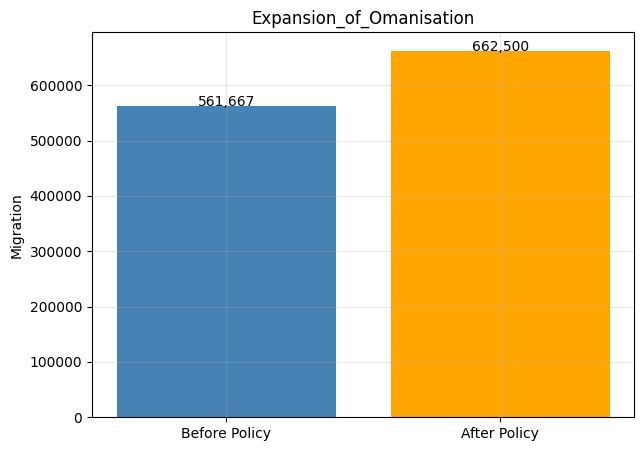


Variance Explained
[0.6234 0.2587 0.0866]
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     106.7
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.21e-19
Time:                        15:56:21   Log-Likelihood:                -443.75
No. Observations:                  37   AIC:                             901.5
Df Residuals:                      30   BIC:                             912.8
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

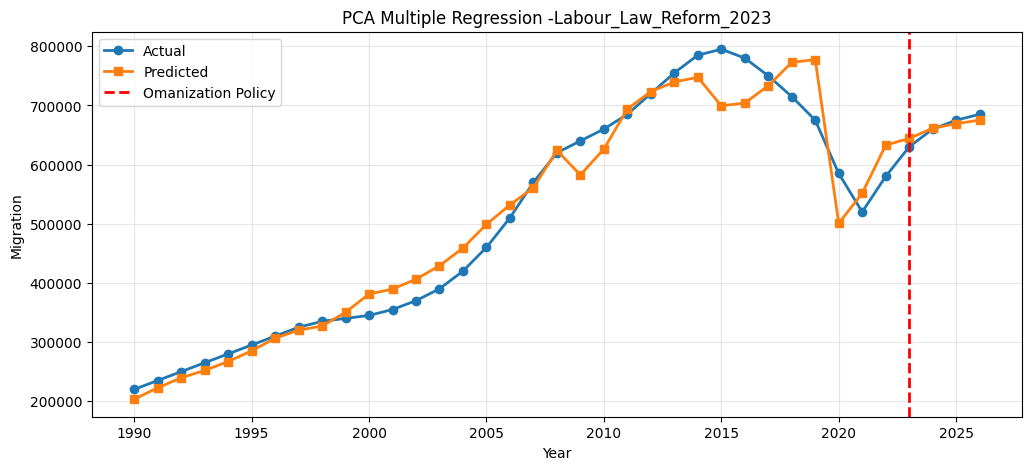

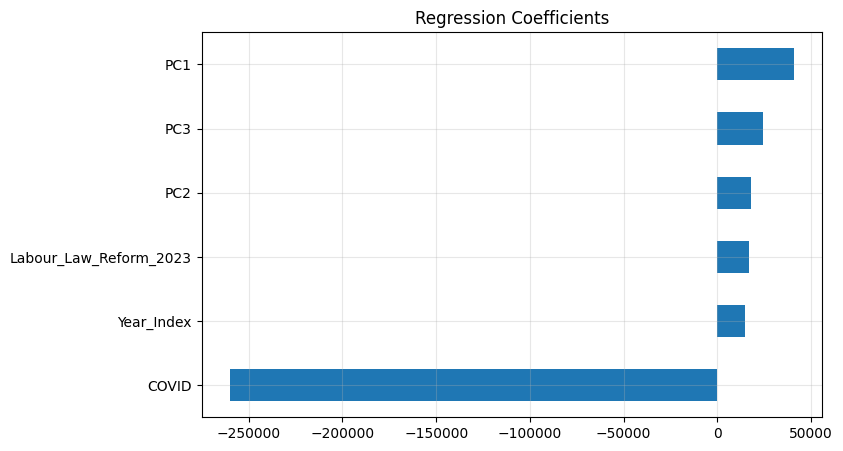

ENHANCED INTERRUPTED TIME SERIES
Policy : Labour_Law_Reform_2023
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.970
Model:                            OLS   Adj. R-squared:                  0.960
Method:                 Least Squares   F-statistic:                     153.8
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           7.92e-21
Time:                        15:56:22   Log-Likelihood:                -436.40
No. Observations:                  37   AIC:                             892.8
Df Residuals:                      27   BIC:                             908.9
Df Model:                           9                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 9
  warnings.warn('covariance of constraints does not have full '


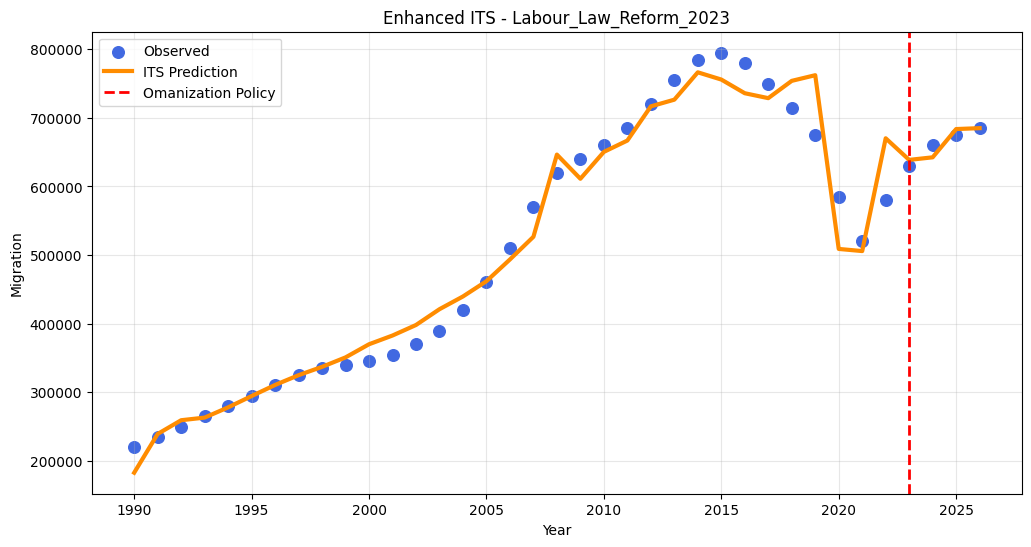

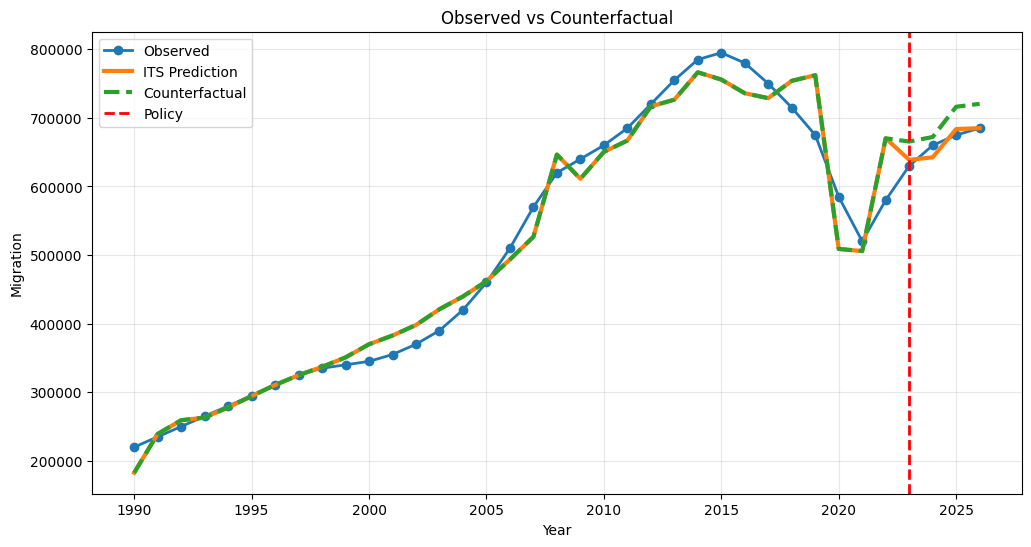

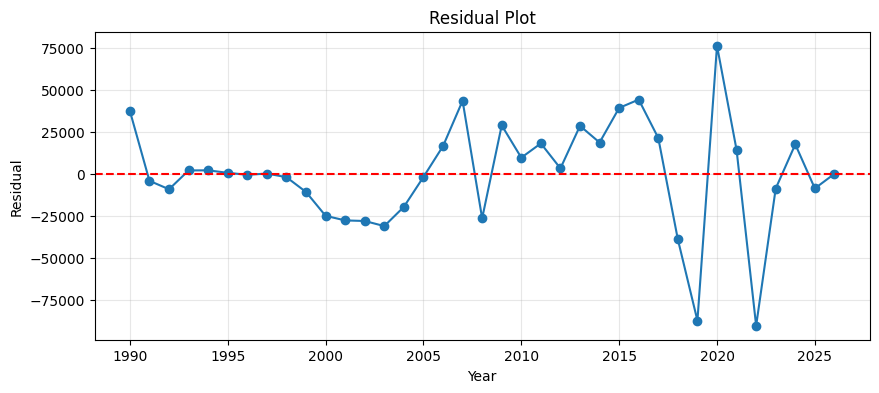

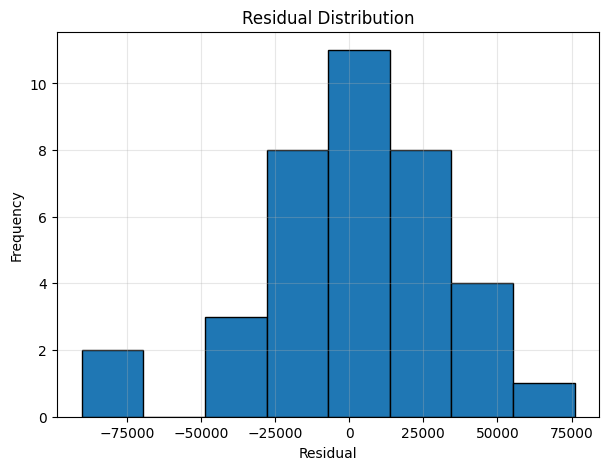


Durbin-Watson : 1.824

INTERPRETATION
✗ No statistically significant immediate change in migration after the policy.
✗ No statistically significant long-term trend change after the policy.

Estimated Immediate Effect : -26693.89
Estimated Annual Trend Change : -1461.06


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

oman = df[df["Country"]=="Oman"].copy()

# ======================================================
# POLICY
# ======================================================

policy = "Labour_Law_Reform_2023"

policy_year = oman.loc[
    oman[policy] == 1,
    "Year"
].min()

print("="*60)
print("Policy :", policy)
print("Policy Year :", policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = oman[
    (oman["Year"] >= policy_year-3) &
    (oman["Year"] < policy_year)
]

after = oman[
    oman["Year"] >= policy_year
]

print("\n========== DESCRIPTIVE ANALYSIS ==========")

print("\nBefore Policy")
print(before["Migration"].describe())

print("\nAfter Policy")
print(after["Migration"].describe())

before_mean = before["Migration"].mean()
after_mean = after["Migration"].mean()

print("\nMean Before :", round(before_mean,2))
print("Mean After  :", round(after_mean,2))
print("Difference  :", round(after_mean-before_mean,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before Policy","After Policy"],
    [before_mean,after_mean],
    color=["steelblue","orange"]
)

for b in bars:
    plt.text(
        b.get_x()+b.get_width()/2,
        b.get_height(),
        f"{b.get_height():,.0f}",
        ha="center"
    )

plt.title("Expansion_of_Omanisation")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# PCA + MULTIPLE REGRESSION
# ======================================================

oman["COVID"]=(oman["Year"]>=2020).astype(int)

oman["Year_Index"]=oman["Year"]-oman["Year"].min()

economic_variables=[

    "Population",
    "GDP",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"

]

X=oman[economic_variables]

X=X.fillna(X.median())

y=oman["Migration"]

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

pca=PCA(n_components=0.95)

X_pca=pca.fit_transform(X_scaled)

print("\nVariance Explained")

print(np.round(
    pca.explained_variance_ratio_,
    4
))

columns=[]

for i in range(X_pca.shape[1]):
    columns.append(f"PC{i+1}")

pca_df=pd.DataFrame(
    X_pca,
    columns=columns,
    index=oman.index
)

reg_data=pd.concat([

pca_df,

oman[[

"Migration",
"COVID",
"Year_Index",
policy

]]

],axis=1)

formula="Migration ~ "

formula+=" + ".join(columns)

formula+=" + COVID + Year_Index + "+policy

model=smf.ols(
    formula,
    data=reg_data
).fit()

print(model.summary())

reg_data["Prediction"]=model.predict(reg_data)

print("\n========== MODEL PERFORMANCE ==========")

print(
"R² :",
round(
r2_score(
reg_data["Migration"],
reg_data["Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
reg_data["Migration"],
reg_data["Prediction"]
)
),2)
)

# ======================================================
# VISUALIZATION
# ======================================================

plt.figure(figsize=(12,5))

plt.plot(

oman["Year"],
reg_data["Migration"],

marker="o",

linewidth=2,

label="Actual"

)

plt.plot(

oman["Year"],
reg_data["Prediction"],

marker="s",

linewidth=2,

label="Predicted"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("PCA Multiple Regression -Labour_Law_Reform_2023")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# REGRESSION COEFFICIENTS
# ======================================================

coef=model.params.drop("Intercept")

coef.sort_values().plot(

kind="barh",

figsize=(8,5)

)

plt.title("Regression Coefficients")

plt.grid(alpha=.3)

plt.show()


# ======================================================
# STEP 2 : ENHANCED INTERRUPTED TIME SERIES (ITS)
# OMANIZATION POLICY
# ======================================================

import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.stattools import durbin_watson
import matplotlib.pyplot as plt
import numpy as np

# ======================================================
# SORT DATA
# ======================================================

oman = oman.sort_values("Year").copy()

# ======================================================
# TIME VARIABLES
# ======================================================

oman["Time"] = oman["Year"] - policy_year

# Policy Indicator

oman["Policy"] = (oman["Year"] >= policy_year).astype(int)

# Time After Policy

oman["Time_After"] = oman["Time"].clip(lower=0)

# Interaction

oman["Policy_Time"] = oman["Policy"] * oman["Time_After"]

# COVID Dummy

oman["COVID"] = (oman["Year"] >= 2020).astype(int)

# ======================================================
# ENHANCED ITS MODEL
# ======================================================

its = smf.ols(

"""

Migration ~

Time +

Policy +

Time_After +

Policy_Time +

Population +

GDP +

Inflation +

Oil_Price +

Exchange_Rate +

Unemployment +

COVID

""",

data=oman

).fit(

cov_type="HAC",

cov_kwds={"maxlags":2}

)

print("="*70)
print("ENHANCED INTERRUPTED TIME SERIES")
print("Policy :", policy)
print("="*70)

print(its.summary())

# ======================================================
# PREDICTION
# ======================================================

oman["ITS_Prediction"] = its.predict(oman)

# ======================================================
# MODEL PERFORMANCE
# ======================================================

print("\nITS PERFORMANCE")
print("-"*40)

print(
"R² :",
round(
r2_score(
oman["Migration"],
oman["ITS_Prediction"]
),4)
)

print(
"RMSE :",
round(
np.sqrt(
mean_squared_error(
oman["Migration"],
oman["ITS_Prediction"]
)
),2)
)

# ======================================================
# POLICY EFFECT
# ======================================================

print("\nPolicy Effect")
print("-"*40)

print("Immediate Level Change :", round(its.params["Policy"],2))
print("Trend Change :", round(its.params["Policy_Time"],2))
print("Time Effect :", round(its.params["Time"],2))

print("\nP-values")
print("Policy :", round(its.pvalues["Policy"],4))
print("Policy_Time :", round(its.pvalues["Policy_Time"],4))

# ======================================================
# OBSERVED VS PREDICTED
# ======================================================

plt.figure(figsize=(12,6))

plt.scatter(

oman["Year"],
oman["Migration"],

s=70,

color="royalblue",

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

color="darkorange",

label="ITS Prediction"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Omanization Policy"

)

plt.title("Enhanced ITS - Labour_Law_Reform_2023")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# COUNTERFACTUAL
# ======================================================

counter = oman.copy()

counter["Policy"] = 0
counter["Policy_Time"] = 0
counter["Time_After"] = 0

counter["Counterfactual"] = its.predict(counter)

plt.figure(figsize=(12,6))

plt.plot(

oman["Year"],
oman["Migration"],

marker="o",

linewidth=2,

label="Observed"

)

plt.plot(

oman["Year"],
oman["ITS_Prediction"],

linewidth=3,

label="ITS Prediction"

)

plt.plot(

counter["Year"],
counter["Counterfactual"],

linestyle="--",

linewidth=3,

label="Counterfactual"

)

plt.axvline(

policy_year,

color="red",

linestyle="--",

linewidth=2,

label="Policy"

)

plt.title("Observed vs Counterfactual")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# RESIDUALS
# ======================================================

oman["Residuals"] = (

oman["Migration"] -

oman["ITS_Prediction"]

)

plt.figure(figsize=(10,4))

plt.plot(

oman["Year"],

oman["Residuals"],

marker="o"

)

plt.axhline(

0,

color="red",

linestyle="--"

)

plt.title("Residual Plot")

plt.xlabel("Year")

plt.ylabel("Residual")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# RESIDUAL HISTOGRAM
# ======================================================

plt.figure(figsize=(7,5))

plt.hist(

oman["Residuals"],

bins=8,

edgecolor="black"

)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(alpha=.3)

plt.show()

# ======================================================
# DURBIN-WATSON
# ======================================================

dw = durbin_watson(its.resid)

print("\nDurbin-Watson :", round(dw,3))

# ======================================================
# INTERPRETATION
# ======================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

if its.pvalues["Policy"] < 0.05:
    print("✓ Omanization Policy caused a statistically significant immediate change in migration.")
else:
    print("✗ No statistically significant immediate change in migration after the policy.")

if its.pvalues["Policy_Time"] < 0.05:
    print("✓ The long-term migration trend changed significantly after the policy.")
else:
    print("✗ No statistically significant long-term trend change after the policy.")

print("\nEstimated Immediate Effect :", round(its.params["Policy"],2))
print("Estimated Annual Trend Change :", round(its.params["Policy_Time"],2))

prophet model for oman


========== OMAN FORECAST (2027-2030) ==========

    Year Predicted_Migration Lower_Bound Upper_Bound
37  2027             595,460     542,055     651,125
38  2028             583,079     528,844     638,409
39  2029             570,665     514,737     625,523
40  2030             558,284     499,195     612,341


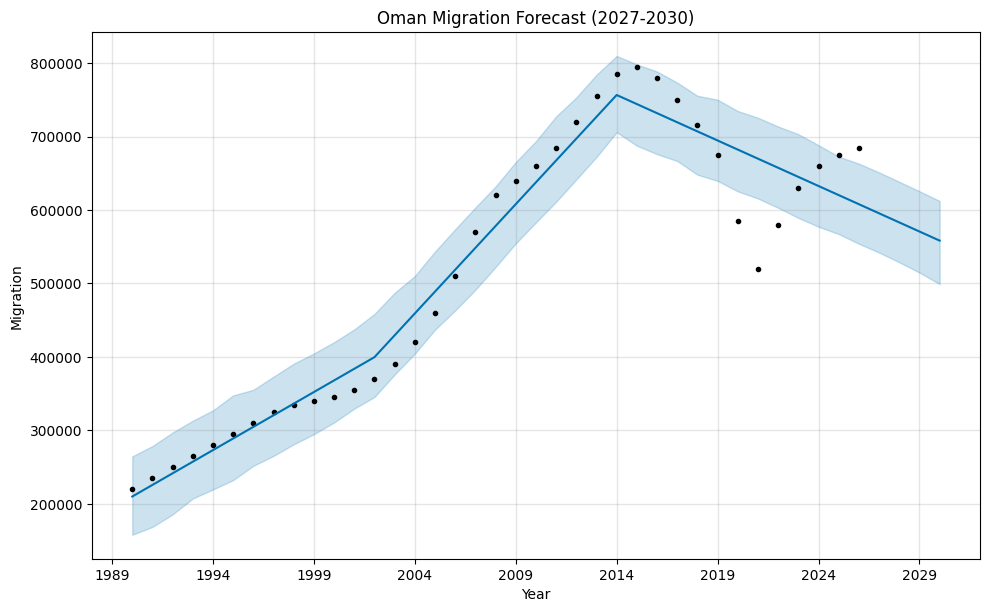

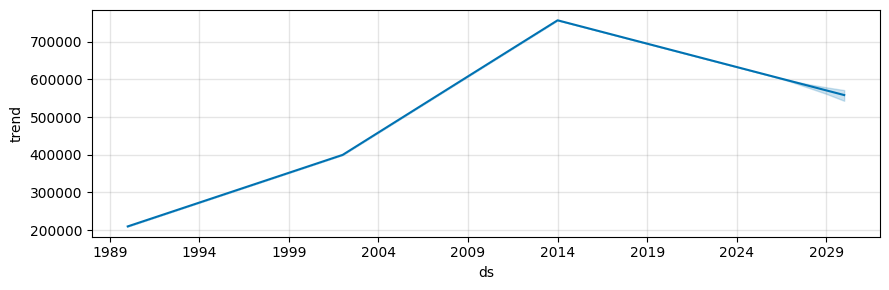

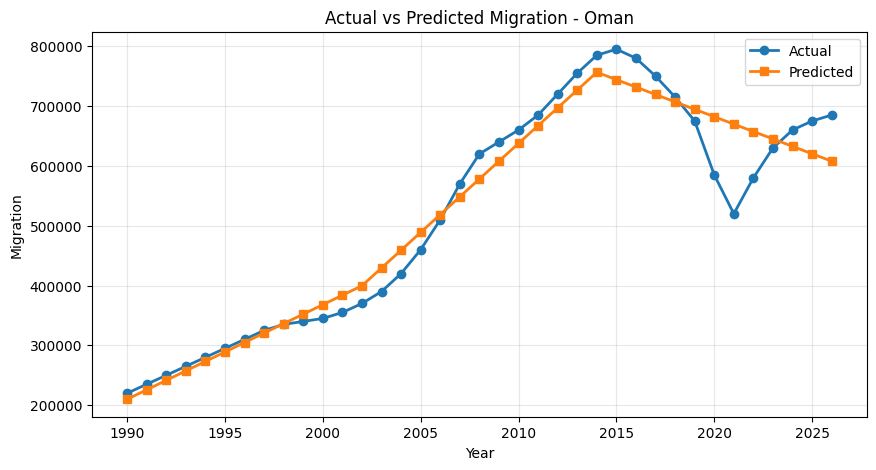


========== MODEL PERFORMANCE ==========

Country : Oman
Mean Migration : 518,649
RMSE : 42,594.02
MAE : 30,819.54
RMSE Percentage : 8.21%
MAE Percentage : 5.94%
MAPE : 5.78%
Forecast Accuracy : 94.22%

Forecast saved as 'Oman_Migration_Forecast_2027_2030.xlsx'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================
# DISPLAY SETTINGS
# =====================================================

pd.set_option('display.float_format', '{:,.2f}'.format)

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_excel("/content/finaldatset_with_policy.xlsx")

# =====================================================
# SELECT COUNTRY
# =====================================================

country = "Oman"

df = df[df["Country"] == country].copy()

df = df.sort_values("Year")

# =====================================================
# PREPARE DATA
# =====================================================

prophet_df = df[["Year", "Migration"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"].astype(str) + "-01-01"
)

# =====================================================
# BUILD PROPHET MODEL
# =====================================================

model = Prophet(

    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.2

)

model.fit(prophet_df)

# =====================================================
# FORECAST TO 2030
# =====================================================

future = model.make_future_dataframe(

    periods=4,
    freq="YS"

)

forecast = model.predict(future)

# =====================================================
# FORECAST TABLE
# =====================================================

forecast_2030 = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].copy()

forecast_2030["Year"] = forecast_2030["ds"].dt.year

forecast_2030 = forecast_2030[
    forecast_2030["Year"] >= 2027
]

forecast_2030 = forecast_2030[
    ["Year", "yhat", "yhat_lower", "yhat_upper"]
]

forecast_2030.columns = [
    "Year",
    "Predicted_Migration",
    "Lower_Bound",
    "Upper_Bound"
]

# Round values

forecast_2030 = forecast_2030.round(0)

forecast_2030["Predicted_Migration"] = forecast_2030["Predicted_Migration"].astype(int)
forecast_2030["Lower_Bound"] = forecast_2030["Lower_Bound"].astype(int)
forecast_2030["Upper_Bound"] = forecast_2030["Upper_Bound"].astype(int)

# Display with commas

forecast_display = forecast_2030.copy()

forecast_display["Predicted_Migration"] = forecast_display["Predicted_Migration"].map('{:,}'.format)
forecast_display["Lower_Bound"] = forecast_display["Lower_Bound"].map('{:,}'.format)
forecast_display["Upper_Bound"] = forecast_display["Upper_Bound"].map('{:,}'.format)

print("\n========== OMAN FORECAST (2027-2030) ==========\n")

print(forecast_display)

# =====================================================
# FORECAST GRAPH
# =====================================================

fig = model.plot(forecast)

plt.title("Oman Migration Forecast (2027-2030)")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(True)

plt.show()

# =====================================================
# COMPONENTS
# =====================================================

fig2 = model.plot_components(forecast)

plt.show()

# =====================================================
# ACTUAL VS PREDICTED
# =====================================================

prediction = forecast.iloc[:len(prophet_df)]

plt.figure(figsize=(10,5))

plt.plot(
    prophet_df["ds"].dt.year,
    prophet_df["y"],
    marker="o",
    linewidth=2,
    label="Actual"
)

plt.plot(
    prophet_df["ds"].dt.year,
    prediction["yhat"],
    marker="s",
    linewidth=2,
    label="Predicted"
)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Actual vs Predicted Migration - Oman")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

# =====================================================
# MODEL PERFORMANCE
# =====================================================

actual = prophet_df["y"].values

predicted = prediction["yhat"].values

rmse = np.sqrt(mean_squared_error(actual, predicted))

mae = mean_absolute_error(actual, predicted)

mean_migration = actual.mean()

rmse_percent = (rmse / mean_migration) * 100

mae_percent = (mae / mean_migration) * 100

mask = actual != 0

mape = np.mean(
    np.abs((actual[mask] - predicted[mask]) / actual[mask])
) * 100

accuracy = 100 - mape

# =====================================================
# RESULTS
# =====================================================

print("\n========== MODEL PERFORMANCE ==========\n")

print(f"Country : {country}")

print(f"Mean Migration : {mean_migration:,.0f}")

print(f"RMSE : {rmse:,.2f}")

print(f"MAE : {mae:,.2f}")

print(f"RMSE Percentage : {rmse_percent:.2f}%")

print(f"MAE Percentage : {mae_percent:.2f}%")

print(f"MAPE : {mape:.2f}%")

print(f"Forecast Accuracy : {accuracy:.2f}%")

# =====================================================
# SAVE FORECAST
# =====================================================

forecast_2030.to_excel(
    "Oman_Migration_Forecast_2027_2030.xlsx",
    index=False
)

print("\nForecast saved as 'Oman_Migration_Forecast_2027_2030.xlsx'")

In [ ]:
0

0